# scTopDEC paul15 tutorial

April 2026

Author: Pakorn Sagulkoo

In this code, we performed scTopoDEC testing on a benchmark single-cell dataset, paul15, to evaluate whether the model runs without errors, as well as to tune hyperparameters for optimal clustering performance.

## Import the relevant libraries

In [1]:
# Import the libraries
import scTopoDEC as stc
import keras
import tensorflow as tf
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

## Load the dataset

We use paul15 from scanpy as aa benchmark dataet in this code. Further detail of this dataset can be found in this ([link](https://scanpy.readthedocs.io/en/stable/generated/scanpy.datasets.paul15.html))

In [2]:
# Load single-cell dataset
adata = sc.datasets.paul15()

We performed some standard single-cell analysis to look overall patterns of the dataset

/tmp/ipykernel_28202/1258752148.py:12: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata_orig, n_top_genes=2000, flavor='seurat_v3')


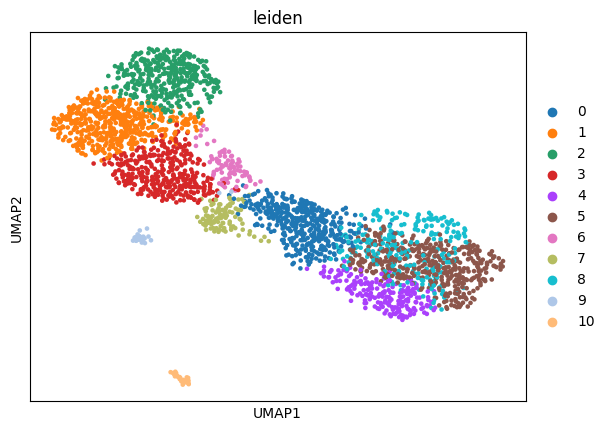

In [ ]:
# scRNA-seq standard pipeline analysis
# 1. Quality control
adata_orig = adata.copy()
sc.pp.filter_genes(adata_orig, min_cells=5)

# 2. Normalisation
adata_orig.layers["counts"] = adata_orig.X.copy() # Saving count data
sc.pp.normalize_total(adata_orig)
sc.pp.log1p(adata_orig)

# 3. Feature selection
sc.pp.highly_variable_genes(adata_orig, n_top_genes=2000, flavor='seurat_v3')

# 4. PCA and UMAP
sc.tl.pca(adata_orig)
sc.pp.neighbors(adata_orig)
sc.tl.umap(adata_orig)

# 5. Clustering
sc.tl.leiden(adata_orig, flavor="igraph", n_iterations=2)
sc.pl.umap(adata_orig, color=["leiden"])

## Run scTopoDEC

Before we run the model, we prepared the data especially the groud truth. We preprocessed the ground truth compatible with our analysis by grouping the same cell types in small clusters into main cell type clusters. We also encoded the string ground truth to make the model can use evalaution metrices to score the dataset.

In [3]:
# scRNA-seq preprocessing for scTopoDEC
# 1. QC
adata_stc = adata.copy()
sc.pp.filter_genes(adata_stc, min_cells=5)
adata_stc.layers["counts"] = adata_stc.X.copy() # Saving count data
sc.pp.normalize_total(adata_stc)
sc.pp.log1p(adata_stc)

# 2. Group main cell types
mapping = {
    '1Ery':'Ery', '2Ery':'Ery', '3Ery':'Ery',
    '4Ery':'Ery', '5Ery':'Ery', '6Ery':'Ery',
    '7MEP':'MEP', '8Mk':'Mk', '9GMP':'GMP',
    '10GMP':'GMP', '11DC':'DC', '12Baso':'Baso',
    '13Baso':'Baso', '14Mo':'Mo', '15Mo':'Mo',
    '16Neu':'Neu', '17Neu':'Neu', '18Eos':'Eos',
    '19Lymph':'Lymph'
}

adata_stc.obs['cell_type'] = adata_stc.obs['paul15_clusters'].map(mapping)

# 3. Create a numerical version of your ground truth
le = LabelEncoder()
adata_stc.obs['cell_type_encoded'] = le.fit_transform(adata_stc.obs['cell_type'])

Now we will run our model. This may take some time, so feel free to grab a cup of coffee or tea while you wait for it to finish.

In [4]:
# Run the model
stc.scTopoDEC(
    adata_stc,
    n_clusters=20,
    n_top_genes=2000,
    hidden_size=(256, 64, 128, 64, 256),
    loss_weights=(1, 1, 0.1, 1),
    noise_sd=0.,
    learning_rate=0.001,
    optimizer='adam',
    update_interval=10,
    ground_truth='cell_type_encoded',
    cluster_early_stop=True,
    soft_kmean=False,
    epochs=500,
    pretrain_learning_rate=0.01,
    pretrain_optimizer='adam',
    reduce_lr=15,
    early_stop=20,
    batch_size=64,
    maximum_edge_length=1.,
    topo_size=45,
    order=1.,
    topo_input_mode='eff_res',
    topo_latent_mode='eff_res',
    n_components=30,
    k=20,
    verbose=True
)

Notice: adata.X appears normalized. Checking 'counts' layer...
Success: Found raw data in 'counts' layer. Swapping to adata.X.
DEC mode: Selecting top 2000 highly variable genes...

...Pretraining Autoencoder...
No pre-trained weights found. Starting fresh pre-training...


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ count (InputLayer)  │ (None, 2000)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0 (Dense)        │ (None, 256)       │    512,256 │ count[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │        768 │ enc0[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_act            │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1 (Dense)        │ (None, 64)        │     16,448 │ enc0_act[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        192 │ enc1[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_act            │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent (Dense)      │ (None, 128)       │      8,320 │ enc1_act[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        384 │ latent[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_act          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec1 (Dense)        │ (None, 64)        │      8,256 │ latent_act[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        192 │ dec1[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec1_act            │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec2 (Dense)        │ (None, 256)       │     16,640 │ dec1_act[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │        768 │ dec2[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec2_act            │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean (Dense)        │ (None, 2000)      │    514,000 │ dec2_act[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ size_factors        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scaled_output       │ (None, 2000)      │          0 │ mean[0][0],       │
│ (ColwiseMultLayer)  │                   │            │ size_factors[0][

 Total params: 2,106,224 (8.03 MB)

 Trainable params: 2,104,688 (8.03 MB)

...

Training DEC:   4%|▍         | 22/500 [07:11<2:40:12, 20.11s/epoch]

Epoch 21 - Total L: 0.8106, L_zinb: 0.6108, L_kl: 0.1710, L_km: 0.0000, L_topo: 0.0288


Training DEC:   4%|▍         | 22/500 [07:31<2:43:28, 20.52s/epoch]

Epoch 22 - Total L: 0.8010, L_zinb: 0.5858, L_kl: 0.1555, L_km: 0.0000, L_topo: 0.0597
Epoch 22: Early stopping triggered.
Restoring best weights from training...
Total Clustering Training complete in 479.03 seconds.
Calculating clustering...


Identified 14 unique clusters.

Algorithm runs successfully!


After the model finishes the running, the final performance is shown here.

In [5]:
# Show the final clustering performance
from scTopoDEC.metric import model_eval
acc, ami, ari, nmi = model_eval(adata_stc, model_clusters='stc_cluster', ground_truth='cell_type_encoded')
print(f"Clustering performance: ACC={acc}, AMI={ami}, ARI={ari}, NMI={nmi}")

Clustering performance: ACC=0.71319, AMI=0.62179, ARI=0.66776, NMI=0.62623


## Visualise the results

After running the model, we visualised the results and compared them with the ground truth and Leiden clustering, a standard method in single-cell data analysis. We also visualised the latent space learned by our model to compare the distribution of cell embeddings with those obtained using UMAP.

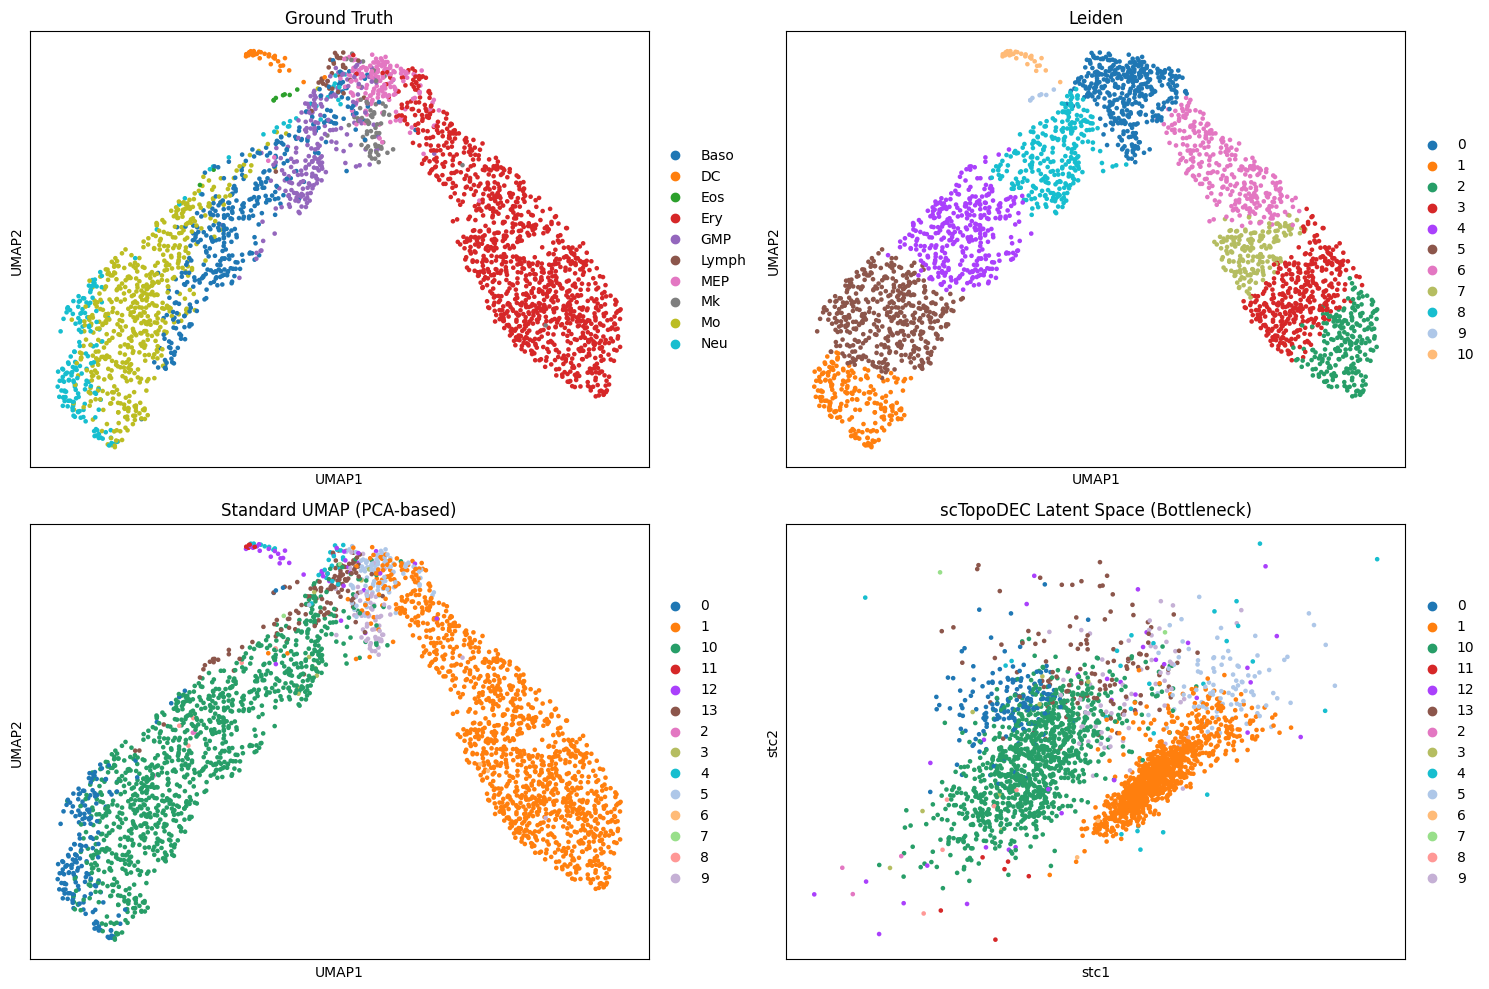

In [6]:
# Data visualisation after the running

# 1. Prepare all embeddings first
sc.pp.highly_variable_genes(adata_stc, n_top_genes=2000, flavor='seurat_v3')
sc.tl.pca(adata_stc)
sc.pp.neighbors(adata_stc) # Standard neighbors for UMAP
sc.tl.umap(adata_stc)      # Computes X_umap
sc.tl.leiden(adata_stc, flavor="igraph", n_iterations=2)

# 2. Setup the figure
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# 3. Left Plot: Standard UMAP
sc.pl.umap(adata_stc, color='cell_type', ax=ax[0, 0], show=False, title="Ground Truth")
sc.pl.umap(adata_stc, color='leiden', ax=ax[0, 1], show=False, title="Leiden")
sc.pl.umap(adata_stc, color='stc_cluster', ax=ax[1, 0], show=False, title="Standard UMAP (PCA-based)")

# 4. Right Plot: scTopoDEC Latent Space
# We plot the embedding directly from the model's bottleneck layer
sc.pl.embedding(adata_stc, basis='stc', color='stc_cluster',
                ax=ax[1, 1], show=False, title="scTopoDEC Latent Space (Bottleneck)")

plt.tight_layout()
plt.show()